In [66]:
import pandas as pd
df = pd.read_csv('price_sample.csv')

In [67]:
# Task 1. Анализ данных

In [68]:
df.head()

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB


In [70]:
df.describe()

,para1,para2,para3,para4,price
count,10003.000000,9997.000000,10003.000000,9998.000000,10003.000000
mean,1.380986,447.270681,9547.975527,8.458024,433.774924
std,3.500408,220.913801,8022.286943,4.613645,277.443154
min,0.000000,16.000000,200.000000,1.000000,50.730000
25%,1.000000,301.000000,2899.500000,4.000000,250.000000
50%,1.000000,434.000000,6446.000000,7.200000,370.000000
75%,1.000000,582.000000,15000.000000,13.600000,550.000000
max,337.000000,2554.000000,34782.000000,27.200000,5700.000000


In [71]:
df.isnull().sum()

para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64

In [72]:
#Task 2. Обработка данных

In [73]:
df = df.drop_duplicates()

In [74]:
df.info()

<class 'pandas.DataFrame'>
Index: 9788 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   9788 non-null   int64  
 1   para2   9782 non-null   float64
 2   para3   9788 non-null   float64
 3   para4   9783 non-null   float64
 4   price   9788 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 458.8 KB


In [75]:
df.dropna(inplace = True)
#Удалила налл значения так как их доля крайне мала (<1%)

In [76]:
df.info()

<class 'pandas.DataFrame'>
Index: 9778 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   9778 non-null   int64  
 1   para2   9778 non-null   float64
 2   para3   9778 non-null   float64
 3   para4   9778 non-null   float64
 4   price   9778 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 458.3 KB


In [77]:
#Task 3. Оценка модели

In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score

In [79]:
X = df.drop('price', axis = 1)
y = df['price']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [81]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
y_pred = model.predict(X_test)

In [83]:
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 
print(f'MSE: {mse}') 
print(f'R^2: {r2}')

MSE: 25492.426778505145
R^2: 0.6837541843991015


In [84]:
# Выбрала регресионную модель поскольку основная цель проекта - прогноз цен
# Изначально построила модель Линейной регрессии но результаты (MSE: 37294.024887189866 R^2: 0.5373496834976037) показались слабыми.
# Поэтому посмотрела другие виды методов в google и выбрала RandomForestRegressor.
# В ходе тестирования данного метода, результаты немного улучшились

In [85]:
df.corr()['price']

para1    0.075271
para2    0.551798
para3    0.358350
para4    0.518270
price    1.000000
Name: price, dtype: float64

In [86]:
#Task 4. Визуализация

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

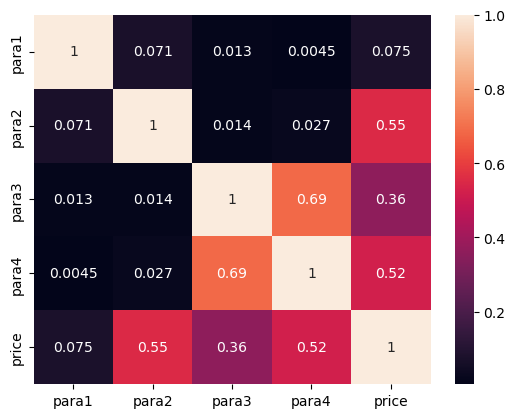

In [88]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.show()

In [89]:
# Провела корреляционный анализ для выявления взаимосвязей между признаками и целевой переменной. 
# Наиболее сильную связь с ценой показал признак para 2, что говорит о его высокой значимости.

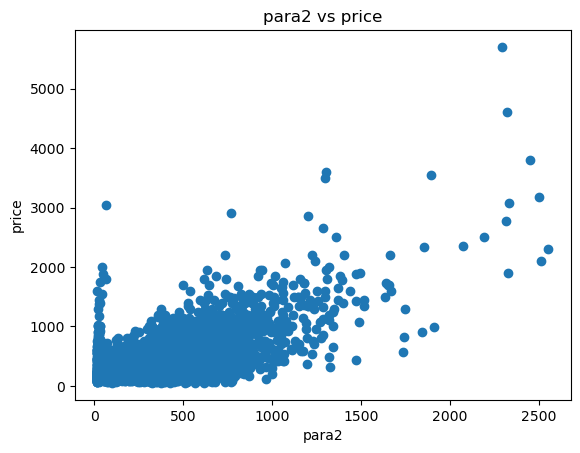

In [90]:
plt.figure()
plt.scatter(df['para2'], df['price'])
plt.xlabel('para2')
plt.ylabel('price')
plt.title('para2 vs price')
plt.show()

In [91]:
#Построила скаттер плот для выявления взаимосвязи между признаком para 2 и ценой:
#Тренд имеется но много шума, связь не идеальная 

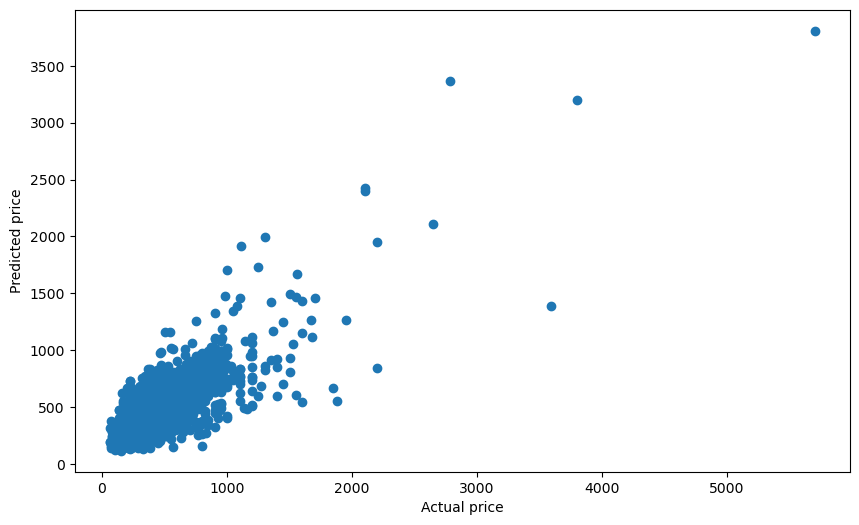

In [94]:
plt.figure(figsize = (10,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.show()

In [ ]:
# Построила график сравнения фактических и предсказанных значений для оценки качества модели.
# График показывает, что модель в целом правильно улавливает тенденцию изменения цены, однако присутствует заметный 
# разброс значений, особенно для высоких цен, что указывает на ограниченность точности предсказаний

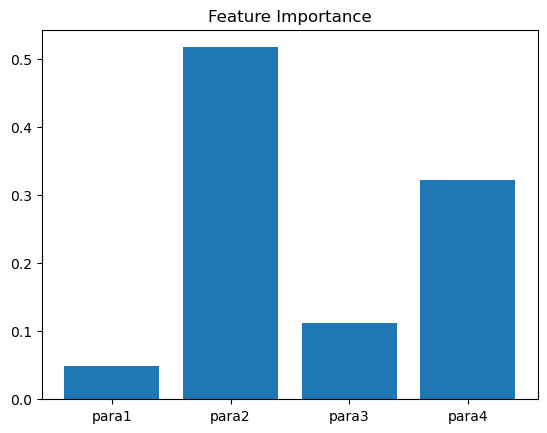

In [95]:
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
# Построила график, который показывает какие признаки наиболее сильно влияют на предсказание цены модели

Итог:
Был проведён анализ данных с использованием корреляционной матрицы, визуализации зависимости признаков и оценки качества модели.
Это позволило выявить влияние отдельных факторов на цену и оценить точность предсказаний модели